In [ ]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_ppo,project_ppo_plus = "mahdikallel", "RLC_PPO_OURS", "PPO_PLUS_FINAL"
runs_ppo_plus = api.runs(entity + "/" + "PPO_PLUS_SUPER_A40")
runs_ppo = api.runs(entity + "/" + "RLC_PPO_OURS")
runs_sac = api.runs(entity + "/" + "sac_benchmark2")

runs = itertools.chain(runs_ppo_plus,runs_ppo,runs_sac)



def filter_fn(run,env_name, filter_dict):

    
    if run.config["env_name"]==env_name:
        for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        return True
    return False



dc = { 
        "PPO+":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":1.,"buffer_size":50000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        "PPO":{"algo_name":"ppo","gamma":0.99},
        "PPO(ours)":{"algo_name":"ppo_ours","gamma":0.99},
         "SAC":{"algo_name":"sac","gamma":0.99},
}
      
      

legends = [""]
env_names = ["InvertedDoublePendulum-v5","Hopper-v5","Walker2d-v5","HalfCheetah-v5","Ant-v5","Humanoid-v5"]
# #env_names =  ["Hopper-v5"]
max_steps = [2e5,1e6,1e6,1e6,1e6,5e6]
legend = [True,False,False,False,False,False]


for env_name,max_step,legend in zip(env_names,max_steps,legend):


    for algo in dc.keys():
        
            print(algo,env_name)
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
                if filter_fn(run,env_name,dc[algo]):
                    
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                    window = 1 if env_name == "InvertedDoublePendulum-v5" else 5
                    tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=window).mean()
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    tmp_df = tmp_df[["step","average return"]]
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    print(run.name)
                    #print("DF_TEMP",df)



            #runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            #print(df)
            df2 = df[df["step"]<int(max_step)]
            x = df2.groupby("step")["step"].mean()/1e6
            mean = df2.groupby("step")["average return"].mean()
            stderror = df2.groupby("step")["average return"].std()/np.sqrt(df2.groupby("step")["average return"].count())
            #stderror = df2.groupby("step")["average return"].std()

            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Policy Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            runs = itertools.chain(runs_ppo_plus,runs_ppo,runs_sac)


    if legend : plt.legend()      
    plt.savefig("./plots/benchmarks/"+env_name+"_benchmark.pdf", format="pdf", bbox_inches="tight")  
    plt.show()

In [ ]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_ppo,project_ppo_plus = "mahdikallel", "RLC_PPO_OURS", "PPO_PLUS_FINAL"
runs_ppo_plus = api.runs(entity + "/" + "PPO_PLUS_SUPER_A40")

runs = itertools.chain(runs_ppo_plus)



def filter_fn(run,env_name, filter_dict):

    
    if run.config["env_name"]==env_name:
        for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        return True
    return False



dc = { 
        "PPO+":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":1.,"buffer_size":50000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        "On policy critic":{"algo_name":"superppo","gamma":0.99,"on_policy_data":True,"temperature":1.,"buffer_size":5000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        "No entropy":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":0.,"buffer_size":50000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5,"min_target":False},
        "Unbounded actions":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":1.,"buffer_size":50000,"use_layer_norm":True,"clipping_ratio":0.25,"num_critics":2,"bound_actions":False,"gae_lambda":0.5,"min_target":False},
        #"No LN ":{"algo_name":"superppo","gamma":0.99,"on_policy_data":False,"temperature":1.,"buffer_size":50000,"use_layer_norm":False,"clipping_ratio":0.25,"num_critics":2,"bound_actions":True,"gae_lambda":0.5},
}
      
      

legends = [""]
env_names = ["InvertedDoublePendulum-v5","Hopper-v5","Walker2d-v5","HalfCheetah-v5","Ant-v5","Humanoid-v5"]
#env_names =  ["Hopper-v5"]
max_steps = [2e5,1e6,1e6,1e6,1e6,5e6]
legend = [True,False,False,False,False,False]

for env_name,max_step,legend in zip(env_names,max_steps,legend):


    for algo in dc.keys():
        
            print(algo,env_name)
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            count = 0
            for run in runs:
                if filter_fn(run,env_name,dc[algo]):
                    
                    count += 1
                    
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                    window = 1 if env_name == "InvertedDoublePendulum-v5" else 5
                    tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=window).mean()
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    tmp_df = tmp_df[["step","average return"]]
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    print(run.name)
                    
                    #print("DF_TEMP",df)
                
                if count == 5:
                    break



            #runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            #print(df)
            df2 = df[df["step"]<int(max_step)]
            x = df2.groupby("step")["step"].mean()/1e6
            mean = df2.groupby("step")["average return"].mean()
            stderror = df2.groupby("step")["average return"].std()/np.sqrt(df2.groupby("step")["average return"].count())
            #stderror = df2.groupby("step")["average return"].std()

            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Policy Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            runs = itertools.chain(runs_ppo_plus)
            #runs = runs_sac

    if legend : plt.legend()      
    plt.savefig("./plots/ablations/"+env_name+"_ablation.pdf", format="pdf", bbox_inches="tight")  
    plt.show()

In [ ]:
# import wandb
# api = wandb.Api()
# entity = "mahdikallel"
# project_name = "sac_benchmark2"
# runs = api.runs(entity + "/" + project_name)

# for run in runs:
#     print(f"Updating run: {run.name}")
#     # Copy the existing configuration and add the new entry
    
#     #run.config["env_name"] = run.config["_fields"]["env_name"]
#     run.config["gamma"]=0.99
#     # Update the run config. Note: Updating finished runs may be restricted.
#     run.update()

In [ ]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity = "mahdikallel"
#runs = api.runs(entity + "/" +"RLC_GRAD_EXPS_5")
runs = api.runs(entity + "/" +"RLC_GRAD_EXPS_5000")
#runs = runs_ppo



def filter_fn(run, algo_name, filter_dict):

    
    for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        
    
    #if run.name!="revived-butterfly-23": return False
    
    return True
    



dc = { 
        "2_1":{"state_dim":2,"a_dim":1},   
        "4_2":{"state_dim":4,"a_dim":2},   
        "6_3":{"state_dim":6,"a_dim":3},   
}

metrics = ["train/cosine_true_normal", "train/cosine_true_no", "train/cosine_true_on", "train/cosine_true_min"]
      
      

max_steps = [1e6]
legend = [True]

for max_step,legend in zip(max_steps,legend):


    algo_name = dc.keys()
    for algo in algo_name:
        
            #print(algo,env_name)
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
                
                if filter_fn(run,algo,dc[algo]):
                    
                    print(run.name)
                    
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    
                    tmp_df = full_df[metrics + ['_step']].dropna(axis=0)
                    #tmp_df = tmp_df.loc[:, (tmp_df != 0).any(axis=0)]
                    #tmp_df = tmp_df[tmp_df['train/cosine_true_estimate'] != 0]
                    #print("TMP DF",tmp_df)
                    #tmp_df = full_df[['train/cosine_true_on','_step']].dropna(axis=0)
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    
                    
                    #break
                    
                 

            
            df2 = df[df["step"]<int(max_step)]
            df2 = df2.drop(columns=['step','_step'])
            sns.boxplot(data=df2, palette="Set3")
            medians = df2.median()
            for i, median in enumerate(medians):
                plt.text(i, median, f'{median:.2f}', ha='center', va='bottom', fontsize=12, color='black')
            plt.xticks(rotation=45, fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Metrics', fontsize=22)
            plt.ylabel('Values', fontsize=22)
            plt.title('Boxplot of Metrics', fontsize=22)
            plt.show()

    if legend : plt.legend()      
    plt.savefig("./plots/grad/"+env_name+"_cosine_"+algo_name+".pdf", format="pdf", bbox_inches="tight")  
    plt.show()

In [ ]:
full_df

swept-grass-31
vague-hill-32
misunderstood-cherry-33
grateful-sun-34
upbeat-universe-35
fresh-dawn-36
hardy-sun-37
sleek-snow-38
fallen-violet-39
brisk-snowball-40


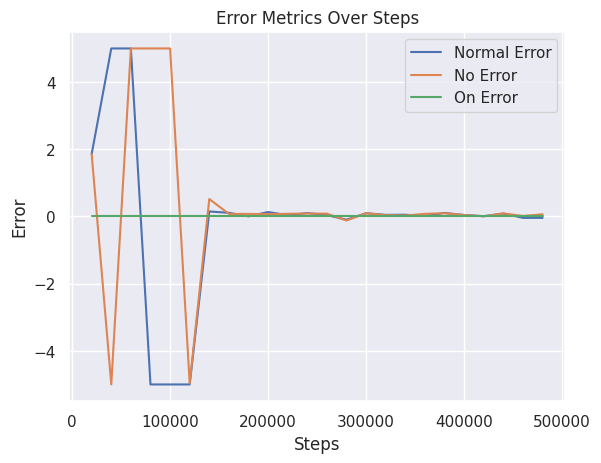

icy-silence-21
fragrant-forest-22
pretty-night-23
morning-smoke-24
feasible-wave-24
floral-sky-26
winter-snow-28
ruby-morning-27
firm-dream-29
fiery-pyramid-29


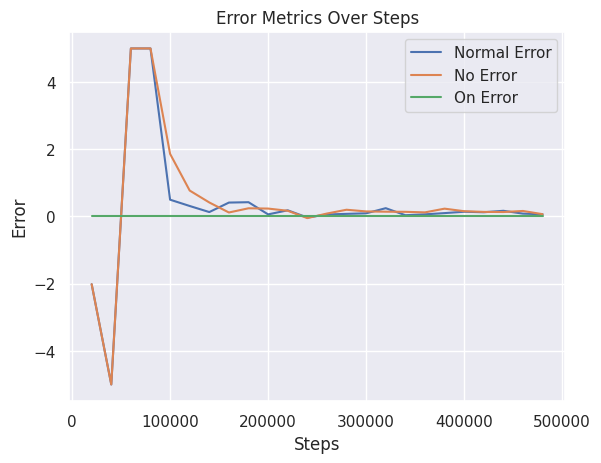

/tmp/ipykernel_603565/838947858.py:99: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if legend : plt.legend()


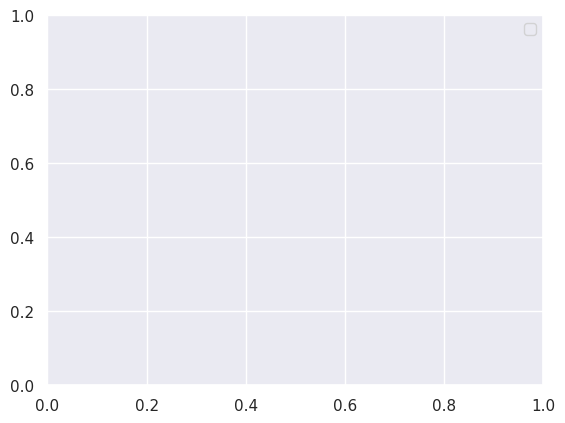

In [31]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity = "mahdikallel"
#runs = api.runs(entity + "/" +"RLC_GRAD_EXPS3")
runs = api.runs(entity + "/" +"RLC_GRAD_EXPS_5000")
#runs = runs_ppo


def filter_fn(run, algo_name, filter_dict):

    
    for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        
    
    #if run.name!="revived-butterfly-23": return False
    
    return True

dc = { 
        "2_1":{"state_dim":2,"a_dim":1},   
        "4_2":{"state_dim":4,"a_dim":2},   
}

metrics = ["train/normal_error", "train/no_error", "train/on_error","train/min_error"]
      
      

max_steps = [5e5]
legend = [True]

for max_step,legend in zip(max_steps,legend):


    algo_name = dc.keys()
    for algo in algo_name:
        
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
     
                if filter_fn(run,algo,dc[algo]):
                    
                    print(run.name)
                    
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=100)
                    tmp_df = full_df[metrics + ['_step']].dropna(axis=0)
                    tmp_df = tmp_df.loc[:, (tmp_df != 0).any(axis=0)]
                    #tmp_df = tmp_df[tmp_df['test/normal_error'] != 0]
                    # for col in metrics:
                    #     tmp_df[col] = pd.to_numeric(tmp_df[col], errors='coerce')
                    # tmp_df["test/on_error"] = pd.to_numeric(tmp_df["test/on_error"], errors='coerce')
                    for col in metrics:
                        #print(tmp_df[col])
                        tmp_df[col] = tmp_df[col] - tmp_df["train/on_error"]
                    
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    
                    
                    #break
                    
                 

            
            df2 = df[(df["step"] < int(max_step)) & (df["step"] > 10_000)]
            grouped = df2.groupby("step").mean().reset_index()
       
            #grouped["train/min_error"] = grouped["train/min_error"].clip(lower=grouped["train/min_error"].quantile(0.), upper=grouped["train/min_error"].quantile(0.8))
            grouped[metrics] = grouped[metrics].clip(lower=-5,upper=5, axis=1)
            
            sns.lineplot(data=grouped, x='step', y='train/normal_error', label='Normal Error')
            sns.lineplot(data=grouped, x='step', y='train/no_error', label='No Error')
            sns.lineplot(data=grouped, x='step', y='train/on_error', label='On Error')
            #sns.lineplot(data=grouped, x='step', y='train/min_error', label='Min Error')
            plt.xlabel('Steps')
            plt.ylabel('Error')
            plt.title('Error Metrics Over Steps')
            plt.legend()
            plt.show()

    if legend : plt.legend()      
    plt.savefig("./plots/grad/"+algo+"_benchmark.pdf", format="pdf", bbox_inches="tight")  
    plt.show()

In [19]:
grouped["train/min_error"].quantile(0.8)

np.float64(42.11307443618777)

In [ ]:
grouped

swept-grass-31
vague-hill-32
misunderstood-cherry-33
grateful-sun-34
upbeat-universe-35
fresh-dawn-36
hardy-sun-37
sleek-snow-38
fallen-violet-39
brisk-snowball-40


/tmp/ipykernel_605824/2654220050.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["step"] = df2["step"] / 1e6


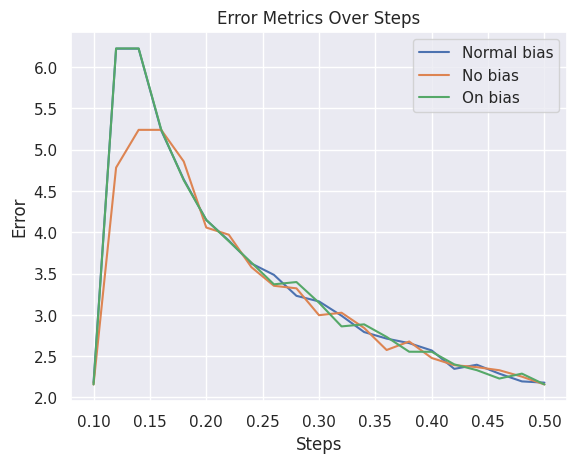

icy-silence-21
fragrant-forest-22
pretty-night-23
morning-smoke-24
feasible-wave-24
floral-sky-26
winter-snow-28
ruby-morning-27
firm-dream-29
fiery-pyramid-29


/tmp/ipykernel_605824/2654220050.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["step"] = df2["step"] / 1e6


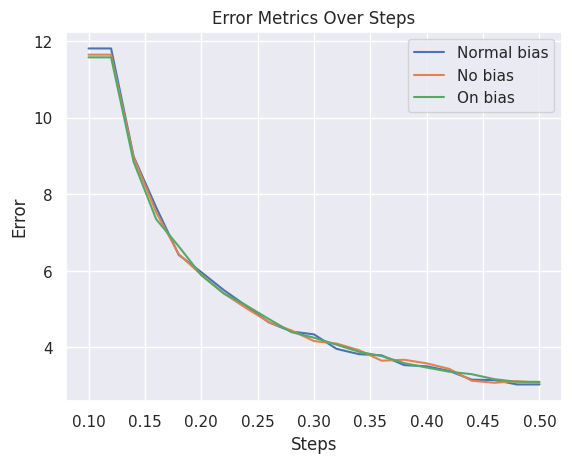

/tmp/ipykernel_605824/2654220050.py:108: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if legend : plt.legend()


NameError: name 'env_name' is not defined

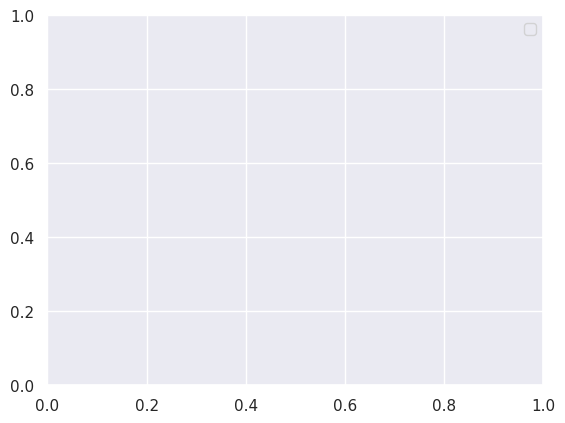

In [11]:
"""" GENERATE BIAS PLOTS"""


import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity = "mahdikallel"
runs = api.runs(entity + "/" +"RLC_GRAD_EXPS_5000")
#runs = runs_ppo


def filter_fn(run, algo_name, filter_dict):

    
    for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        
    
    #if run.name!="revived-butterfly-23": return False
    
    return True

dc = {  
        "2_1":{"state_dim":2,"a_dim":1},   
        "4_2":{"state_dim":4,"a_dim":2},   
        
}

metrics = ["train/normal_bias", "train/no_bias", "train/on_bias","train/min_bias"]
      
      

max_steps = [5e5]
legend = [True]

for max_step,legend in zip(max_steps,legend):


    algo_name = dc.keys()
    for algo in algo_name:
        
       
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
     
                if filter_fn(run,algo,dc[algo]):
                    
                    print(run.name)
                    
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=100)
                    tmp_df = full_df[metrics + ['_step']].dropna(axis=0)
                    #tmp_df = tmp_df.loc[:, (tmp_df != 0).any(axis=0)]
                    #tmp_df = tmp_df[tmp_df['train/normal_error'] != 0]
                    for col in metrics:
                        tmp_df[col] = pd.to_numeric(tmp_df[col], errors='coerce')
                    tmp_df["train/on_bias"] = pd.to_numeric(tmp_df["train/on_bias"], errors='coerce')
                    #for col in metrics:
                        #print(tmp_df[col])
                        #tmp_df[col] = tmp_df[col] - tmp_df["train/on_bias"]
                    
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    
                    
                    #break
                    
                 

            
            df2 = df[(df["step"]<=500_000) & (df["step"] >= 100_000)]
            df2["step"] = df2["step"] / 1e6
            grouped = df2.groupby("step").mean().reset_index()
            
            # df2 = df2.drop(columns=['step','_step'])
            # sns.boxplot(data=df2, palette="Set3")
            # medians = df2.median()
            # for i, median in enumerate(medians):
            #     plt.text(i, median, f'{median:.2f}', ha='center', va='bottom', fontsize=12, color='black')
            # Clip outliers
            grouped[metrics] = grouped[metrics].clip(lower=grouped[metrics].quantile(0.05), upper=grouped[metrics].quantile(0.95), axis=1)
            
            sns.lineplot(data=grouped, x='step', y='train/normal_bias', label='Normal bias')
            sns.lineplot(data=grouped, x='step', y='train/no_bias', label='No bias')
            sns.lineplot(data=grouped, x='step', y='train/on_bias', label='On bias')
            #sns.lineplot(data=grouped, x='step', y='train/min_bias', label='Min bias')
            plt.xlabel('Steps')
            plt.ylabel('Error')
            plt.title('Error Metrics Over Steps')
            plt.legend()
            plt.show()

    if legend : plt.legend()      
    plt.savefig("./plots/grad/"+env_name+"_benchmark.pdf", format="pdf", bbox_inches="tight")  
    plt.show()

In [4]:
grouped

,step,train/normal_bias,train/no_bias,train/on_bias,train/min_bias,_step
0,20000.0,-4.920081e+08,-4.920081e+08,-4.920081e+08,-4.920081e+08,20000.0
1,40000.0,-4.844594e+08,-4.844594e+08,-4.844594e+08,-4.844594e+08,40000.0
2,60000.0,-1.891859e+08,-1.891860e+08,-1.891858e+08,-1.891860e+08,60000.0
3,80000.0,1.409778e+02,1.377876e+02,1.702302e+02,6.243012e+01,80000.0
4,100000.0,1.803981e+01,1.415441e+01,1.509809e+01,-3.382768e+01,100000.0
5,120000.0,1.180220e+01,1.164007e+01,1.157005e+01,-1.486398e+01,120000.0
6,140000.0,8.982085e+00,8.957006e+00,8.844329e+00,-2.721822e+01,140000.0
7,160000.0,7.655177e+00,7.529537e+00,7.347502e+00,-1.408214e+01,160000.0
8,180000.0,6.418612e+00,6.435651e+00,6.638715e+00,-1.231811e+01,180000.0


In [ ]:
#grouped[metrics].quantile(0.05)
grouped.quantile(0.5)

In [ ]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools
import matplotlib

sns.set(font_scale=3.)
#matplotlib.rcParams.update({'font.size': 28})
sns.set_theme()

matplotlib.rcParams.update({'font.size': 50})



os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "iclr_close", "iclr_ppo_diagnosis"


runs_ppo = api.runs(entity + "/" + "RLC_PPO_DIAGNOSTIC2")
runs = itertools.chain(runs_ppo)



def filter_fn(run,env_name, filter_dict):

    
    if run.config["env_name"]==env_name:
        for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        return True
    return False



env_name = "InvertedDoublePendulum-v5"

dc = {"PPO":{"normalize_reward":True,"normalize_observation":True,"gae_lambda":0.95},
      "PPO (-reward_norm)":{"algo_name":"ppo","normalize_reward":False,"normalize_observation":True,"gae_lambda":0.95},
      "PPO (-obs_norm)":{"algo_name":"ppo","normalize_reward":True,"normalize_observation":False,"gae_lambda":0.95},
      "PPO (lambda=0.7)":{"algo_name":"ppo","normalize_reward":True,"normalize_observation":True,"gae_lambda":0.8},
      "PPO (lambda=0.)":{"algo_name":"ppo","normalize_reward":True,"normalize_observation":True,"gae_lambda":0.},
      }
legends = [""]


env_names = ["Hopper-v5","Walker2d-v5"]
max_steps = [1e6,1e6]
legend = [True,False]



for env_name,max_step,legend in zip(env_names,max_steps,legend):


    
    algo_name = dc.keys()
    
    
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                if filter_fn(run,env_name,dc[algo]):
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                    tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=10).mean()
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    tmp_df = tmp_df[["step","average return"]]
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    print(run.name)

            


            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            #stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())
            stderror = df.groupby("step")["average return"].std()
            
            #plt.axis('equal')
            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Average Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            #runs = itertools.chain(runs_99,runs_995)
            runs = itertools.chain(runs_ppo)

    if legend : plt.legend()      
    plt.savefig("./plots/diagnostics/"+env_name+"diagnostic.pdf", format="pdf", bbox_inches="tight")  
    plt.show()